In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Image loading packages
from PIL import Image
from io import BytesIO
import requests

image_array.shape:  (250, 250)


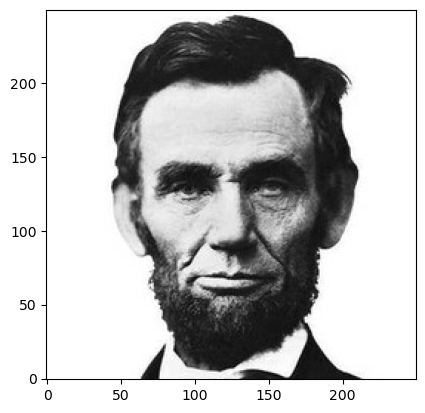

In [3]:
# URL of the image
image_url = 'https://raw.githubusercontent.com/MurpheyLab/ME455_public/main/figs/lincoln.jpg'

# Fetch the image data from the URL
response = requests.get(image_url)

# Create a BytesIO object from the response data
image_data = BytesIO(response.content)

# Open the image using PIL
image = Image.open(image_data)

# Convert the image to a NumPy array
image_array = np.array(image)
image_array = np.flip(image_array, axis=0)

print('image_array.shape: ', image_array.shape)

plt.imshow(image_array, origin='lower', cmap='gray') # note that for "imshow" the origin of the coordinate is at top left instead of bottom left
plt.show()
plt.close()

In [4]:
xgrids = np.linspace(0.0, 1.0, image_array.shape[0])  # the x coordinates of image pixels in the new space
dx = xgrids[1] - xgrids[0]
ygrids = np.linspace(0.0, 1.0, image_array.shape[1])  # the y coordinates of image pixels in the new space
dy = ygrids[1] - ygrids[0]

# we now invert dark and light pixel density and normalize the density values so it is a valid probability distribution
density_array = 255.0 - image_array  # we want higher density at darker regions
density_array /= np.sum(density_array) * dx * dy  # so the integral is 1

def image_density(s):
    """ Continuous density function based on the image
    Inputs:
        s - a numpy array containing the (x,y) coordinate within the 1m-by-1m space
    Return:
        val - the density value at s
    """
    s_x, s_y = s

    # Find the pixel closest to s in the 1-by-1 space
    # Note that in image the first pixel coordinate correspond to the y-axis in the 1-by-1 space
    pixel_idx_y = np.argmin(np.abs(xgrids - s_x))
    pixel_idx_x = np.argmin(np.abs(ygrids - s_y))

    # the density at s is the same as the closest pixel density
    val = density_array[pixel_idx_x, pixel_idx_y]

    return val

In [9]:
def rejection_sample(proposal, proposal_density, num_samples, alpha=5.0):
    """ Rejection sampling algorithm
    Inputs:
        proposal - a function that generates samples from the proposal distribution
        num_samples - the number of samples to generate
    Return:
        samples - a numpy array of shape (num_samples, 2) containing the generated samples
    """
    samples = []
    while len(samples) < num_samples:
        # Generate a sample from the proposal distribution
        s = proposal()

        # Compute the acceptance probability
        beta = image_density(s) / (proposal_density(s) * alpha)

        # Accept or reject the sample
        if np.random.rand() < beta:
            samples.append(s)

    return np.array(samples)

In [7]:
def uniform_proposal():
    return np.random.rand(2)

def uniform_proposal_density(s):
    return 1.0  # the density of uniform distribution over the 1m-by-1m space is 1

def gaussian_proposal():
    return np.random.normal(loc=0.5, scale=0.2, size=2)  # mean at the center of the space, std dev is 0.2

def gaussian_proposal_density(s):
    mean = np.array([0.5, 0.5])
    cov = np.array([[0.2**2, 0], [0, 0.2**2]])
    diff = s - mean
    exponent = -0.5 * diff.T @ np.linalg.inv(cov) @ diff
    return (1.0 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))) * np.exp(exponent)

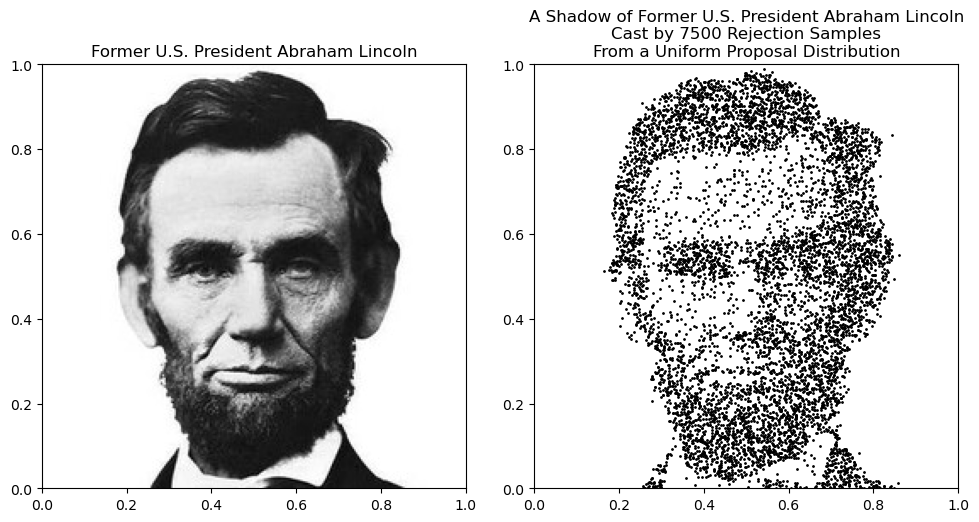

In [30]:
# ── Plot: rejection samples vs. Lincoln image ──────────────────────────────
num_samples = 7500
samples = rejection_sample(uniform_proposal, uniform_proposal_density, num_samples, alpha=5.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ── Left: Lincoln image scaled to [0,1]×[0,1] ─────────────────────────────
axes[0].imshow(
    image_array,
    extent=[0, 1, 0, 1],   # map pixel coords → [0,1]×[0,1]
    origin='lower',
    cmap='gray',
    aspect='equal'
)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_title('Former U.S. President Abraham Lincoln')

# ── Right: rejection-sampling output in [0,1]×[0,1] ───────────────────────
axes[1].scatter(
    samples[:, 0], samples[:, 1],
    s=1, c='black', alpha=1
)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')
axes[1].set_title(f'A Shadow of Former U.S. President Abraham Lincoln\nCast by {num_samples} Rejection Samples\nFrom a Uniform Proposal Distribution')

plt.tight_layout()
plt.show()
plt.close()

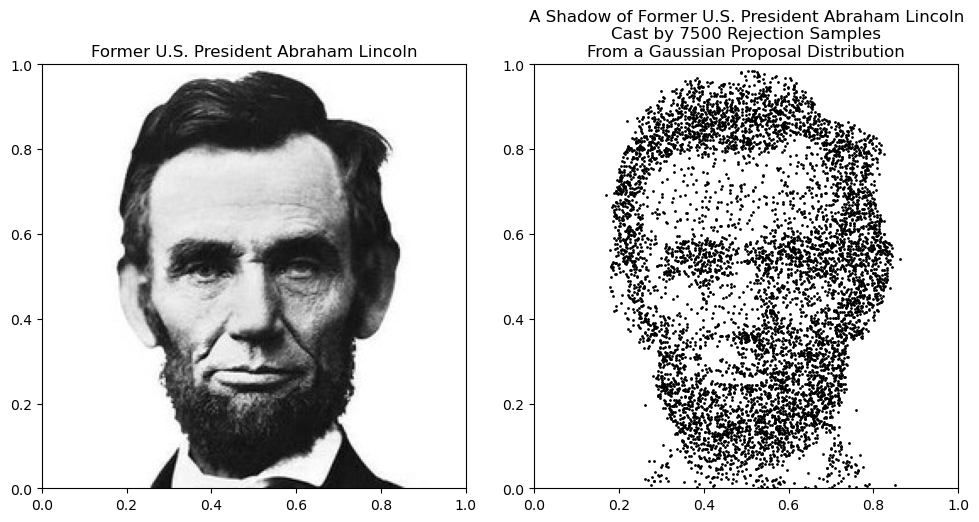

In [31]:
# ── Plot: rejection samples vs. Lincoln image ──────────────────────────────
num_samples = 7500
samples = rejection_sample(gaussian_proposal, gaussian_proposal_density, num_samples, alpha=5.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ── Left: Lincoln image scaled to [0,1]×[0,1] ─────────────────────────────
axes[0].imshow(
    image_array,
    extent=[0, 1, 0, 1],   # map pixel coords → [0,1]×[0,1]
    origin='lower',
    cmap='gray',
    aspect='equal'
)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_title('Former U.S. President Abraham Lincoln')

# ── Right: rejection-sampling output in [0,1]×[0,1] ───────────────────────
axes[1].scatter(
    samples[:, 0], samples[:, 1],
    s=1, c='black', alpha=1
)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')
axes[1].set_title(f'A Shadow of Former U.S. President Abraham Lincoln\nCast by {num_samples} Rejection Samples\nFrom a Gaussian Proposal Distribution')

plt.tight_layout()
plt.show()
plt.close()